# Policy Lever Impact Analysis

This notebook evaluates how key policy levers affect permitting outcomes.

Levers included:
- Staffing levels (planning, public works, fire)
- Permit volume (`num_permits`)

For each scenario, the notebook runs multiple Monte Carlo repetitions and summarizes impacts on:
- Mean total processing time
- Median total processing time
- Completion count
- Mean staff utilization (planning, public works, fire)


In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_multiple_simulations, plot_staff_utilization_series

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
# --- Baseline + policy scenario grid ---
BASE_PARAMS = {
    "name": "baseline",
    "sequential": "standard",
    "ai_review": "none",
    "pct_pre_approved": 0.018,
    "pct_custom": 0.91,
    "pct_self_cert": 0.081,
    "pct_like_for_like": 0.803,
    "pre_application_distribution": "baseline",
    "review_duration_families": None,
    "review_duration_multipliers": None,
    "planning_staff_count": 20,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 30,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 10,
    "fire_caseload_per_staff": 7,
}

N_RUNS = 20
BASE_SEED = 42
SIMULATION_DURATION = None

NUM_PERMITS_OPTIONS = [2000, 6500]

# Scenario dimensions (not policy levers)
STAFFING_SCENARIOS = {
    "low": {"planning_staff_count": 2, "public_works_staff_count": 3, "fire_staff_count": 1},
    "medium": {"planning_staff_count": 8, "public_works_staff_count": 12, "fire_staff_count": 4},
    "high": {"planning_staff_count": 20, "public_works_staff_count": 30, "fire_staff_count": 10},
}
PRE_APPLICATION_DISTRIBUTIONS = ["lognormal_10", "lognormal_60", "lognormal_180"]

# Policy levers
SEQUENTIAL_OPTIONS = ["sequential", "standard", "parallel"]
AI_REVIEW_OPTIONS = ["none", "initial_check", "full_review"]


def build_scenarios():
    scenarios = []
    for (
        num_permits,
        (staffing_name, staffing),
        pre_app_dist,
        sequential_mode,
        ai_mode,
    ) in itertools.product(
        NUM_PERMITS_OPTIONS,
        STAFFING_SCENARIOS.items(),
        PRE_APPLICATION_DISTRIBUTIONS,
        SEQUENTIAL_OPTIONS,
        AI_REVIEW_OPTIONS,
    ):
        scenario = dict(BASE_PARAMS)
        scenario["name"] = (
            f"permits={num_permits}|staffing={staffing_name}|"
            f"preapp={pre_app_dist}|seq={sequential_mode}|ai={ai_mode}"
        )
        scenario["planning_staff_count"] = staffing["planning_staff_count"]
        scenario["public_works_staff_count"] = staffing["public_works_staff_count"]
        scenario["fire_staff_count"] = staffing["fire_staff_count"]
        scenario["pre_application_distribution"] = pre_app_dist
        scenario["sequential"] = sequential_mode
        scenario["ai_review"] = ai_mode
        scenarios.append((num_permits, staffing_name, pre_app_dist, sequential_mode, ai_mode, scenario))
    return scenarios


SCENARIOS = build_scenarios()
print(f"Total scenarios: {len(SCENARIOS)}")
print("Staffing scenarios:", list(STAFFING_SCENARIOS.keys()))
print("Pre-application distributions:", PRE_APPLICATION_DISTRIBUTIONS)
print("Policy levers:")
print("  sequential:", SEQUENTIAL_OPTIONS)
print("  ai_review:", AI_REVIEW_OPTIONS)


Total scenarios: 162
Staffing scenarios: ['low', 'medium', 'high']
Pre-application distributions: ['lognormal_10', 'lognormal_60', 'lognormal_180']
Policy levers:
  sequential: ['sequential', 'standard', 'parallel']
  ai_review: ['none', 'initial_check', 'full_review']


In [3]:
# --- Run experiments ---
rows = []
util_by_scenario = {}

for idx, (num_permits, staffing_name, pre_app_dist, sequential_mode, ai_mode, scenario) in enumerate(SCENARIOS, start=1):
    results, avg_util_by_scenario = run_multiple_simulations(
        n_runs=N_RUNS,
        num_permits=num_permits,
        simulation_duration=SIMULATION_DURATION,
        base_seed=BASE_SEED,
        scenario_params_list=[scenario],
        collect_permits=True,
        collect_average_staff_utilization=True,
        utilization_kind="implied",
        utilization_step=0.1,
    )

    util = avg_util_by_scenario[scenario["name"]]
    util_by_scenario[scenario["name"]] = util

    app_to_ready_mean_by_run = []
    app_to_ready_median_by_run = []
    completed_by_run = []

    for r in results:
        permits = r.get("permits", [])
        durations = [
            (p.ready_for_construction - p.planning_request)
            for p in permits
            if p.ready_for_construction is not None and p.planning_request is not None
        ]
        if durations:
            app_to_ready_mean_by_run.append(float(np.mean(durations)))
            app_to_ready_median_by_run.append(float(np.median(durations)))
        else:
            app_to_ready_mean_by_run.append(np.nan)
            app_to_ready_median_by_run.append(np.nan)
        completed_by_run.append(len(durations))

    rows.append(
        {
            "scenario": scenario["name"],
            "num_permits": num_permits,
            "staffing_scenario": staffing_name,
            "pre_application_distribution": pre_app_dist,
            "sequential": sequential_mode,
            "ai_review": ai_mode,
            "planning_staff_count": scenario["planning_staff_count"],
            "public_works_staff_count": scenario["public_works_staff_count"],
            "fire_staff_count": scenario["fire_staff_count"],
            "application_to_ready_mean_days": float(np.nanmean(app_to_ready_mean_by_run)),
            "application_to_ready_mean_days_std": float(np.nanstd(app_to_ready_mean_by_run, ddof=1) if len(app_to_ready_mean_by_run) > 1 else 0.0),
            "application_to_ready_median_days": float(np.nanmean(app_to_ready_median_by_run)),
            "completed_mean": float(np.mean(completed_by_run)),
            "planning_util_mean_pct": float(100.0 * np.mean(util["planning"])),
            "planning_util_peak_pct": float(100.0 * np.max(util["planning"])),
            "public_works_util_mean_pct": float(100.0 * np.mean(util["public_works"])),
            "public_works_util_peak_pct": float(100.0 * np.max(util["public_works"])),
            "fire_util_mean_pct": float(100.0 * np.mean(util["fire"])),
            "fire_util_peak_pct": float(100.0 * np.max(util["fire"])),
        }
    )

    if idx % 10 == 0 or idx == len(SCENARIOS):
        print(f"Completed {idx}/{len(SCENARIOS)} scenarios")

impact_df = pd.DataFrame(rows)
impact_df.head()



Completed 10/162 scenarios
Completed 20/162 scenarios
Completed 30/162 scenarios
Completed 40/162 scenarios
Completed 50/162 scenarios
Completed 60/162 scenarios
Completed 70/162 scenarios
Completed 80/162 scenarios
Completed 90/162 scenarios
Completed 100/162 scenarios
Completed 110/162 scenarios
Completed 120/162 scenarios
Completed 130/162 scenarios
Completed 140/162 scenarios
Completed 150/162 scenarios
Completed 160/162 scenarios
Completed 162/162 scenarios


,scenario,num_permits,staffing_scenario,pre_application_distribution,sequential,ai_review,planning_staff_count,public_works_staff_count,fire_staff_count,application_to_ready_mean_days,application_to_ready_mean_days_std,application_to_ready_median_days,completed_mean,planning_util_mean_pct,planning_util_peak_pct,public_works_util_mean_pct,public_works_util_peak_pct,fire_util_mean_pct,fire_util_peak_pct
0,permits=2000|staffing=low|preapp=lognormal_10|...,2000,low,lognormal_10,sequential,none,2,3,1,603.416574,6.191633,611.121458,2000.0,19.427683,100.000000,15.857488,86.428571,21.122863,100.0
1,permits=2000|staffing=low|preapp=lognormal_10|...,2000,low,lognormal_10,sequential,initial_check,2,3,1,460.952150,5.413957,472.526823,2000.0,14.408933,100.000000,11.665605,84.761905,15.875597,100.0
2,permits=2000|staffing=low|preapp=lognormal_10|...,2000,low,lognormal_10,sequential,full_review,2,3,1,134.622424,1.355316,126.937112,2000.0,1.944440,89.285714,1.583759,66.666667,2.107444,80.0
3,permits=2000|staffing=low|preapp=lognormal_10|...,2000,low,lognormal_10,standard,none,2,3,1,635.220422,7.021636,635.427392,2000.0,19.391712,100.000000,15.837083,87.142857,21.130392,100.0
4,permits=2000|staffing=low|preapp=lognormal_10|...,2000,low,lognormal_10,standard,initial_check,2,3,1,494.926948,5.275253,495.609964,2000.0,14.432104,100.000000,11.688657,86.428571,15.903753,100.0


In [4]:
# --- Policy lever impacts (parallel vs sequential, AI initial vs full) ---
def effect_span(df, lever, metric):
    grouped = df.groupby(lever, as_index=False)[metric].mean().sort_values(lever)
    return grouped, grouped[metric].max() - grouped[metric].min()

metrics = [
    "application_to_ready_mean_days",
    "application_to_ready_median_days",
    "planning_util_mean_pct",
    "public_works_util_mean_pct",
    "fire_util_mean_pct",
]

policy_levers = ["sequential", "ai_review"]

for metric in metrics:
    print("\n" + "=" * 90)
    print(f"Metric: {metric}")
    print("=" * 90)
    spans = []
    for lever in policy_levers:
        grouped, span = effect_span(impact_df, lever, metric)
        spans.append((lever, span))
        print(f"\nPolicy lever: {lever} (span={span:.2f})")
        display(grouped)

    print("\nPolicy lever rank by effect span:")
    for lever, span in sorted(spans, key=lambda x: x[1], reverse=True):
        print(f"  {lever:24s} {span:10.2f}")

print("\n" + "=" * 90)
print("Policy levers within each staffing / permit / pre-app scenario")
print("=" * 90)
strata_cols = ["num_permits", "staffing_scenario", "pre_application_distribution"]
for keys, group in impact_df.groupby(strata_cols):
    print(f"\nStratum: permits={keys[0]}, staffing={keys[1]}, pre_app={keys[2]}")
    pivot = group.pivot_table(
        index="sequential",
        columns="ai_review",
        values="application_to_ready_mean_days",
        aggfunc="mean",
    )
    display(pivot)



Metric: application_to_ready_mean_days

Policy lever: sequential (span=29.01)


,sequential,application_to_ready_mean_days
0,parallel,356.030916
1,sequential,371.029280
2,standard,385.041353



Policy lever: ai_review (span=433.23)


,ai_review,application_to_ready_mean_days
0,full_review,127.756246
1,initial_check,423.361510
2,none,560.983792



Policy lever rank by effect span:
  ai_review                    433.23
  sequential                    29.01

Metric: application_to_ready_median_days

Policy lever: sequential (span=23.06)


...

ai_review,full_review,initial_check,none
sequential,,,
parallel,153.562888,426.562954,549.110166
sequential,134.182314,423.222350,560.189409
standard,177.140019,470.728950,596.856002



Stratum: permits=6500, staffing=medium, pre_app=lognormal_180


ai_review,full_review,initial_check,none
sequential,,,
parallel,72.658250,314.902918,456.866329
sequential,134.076336,326.215809,490.809920
standard,114.577064,343.629627,488.703289



Stratum: permits=6500, staffing=medium, pre_app=lognormal_60


ai_review,full_review,initial_check,none
sequential,,,
parallel,109.416402,405.113190,537.743622
sequential,134.102217,408.799055,555.674508
standard,136.631392,413.871135,538.512824


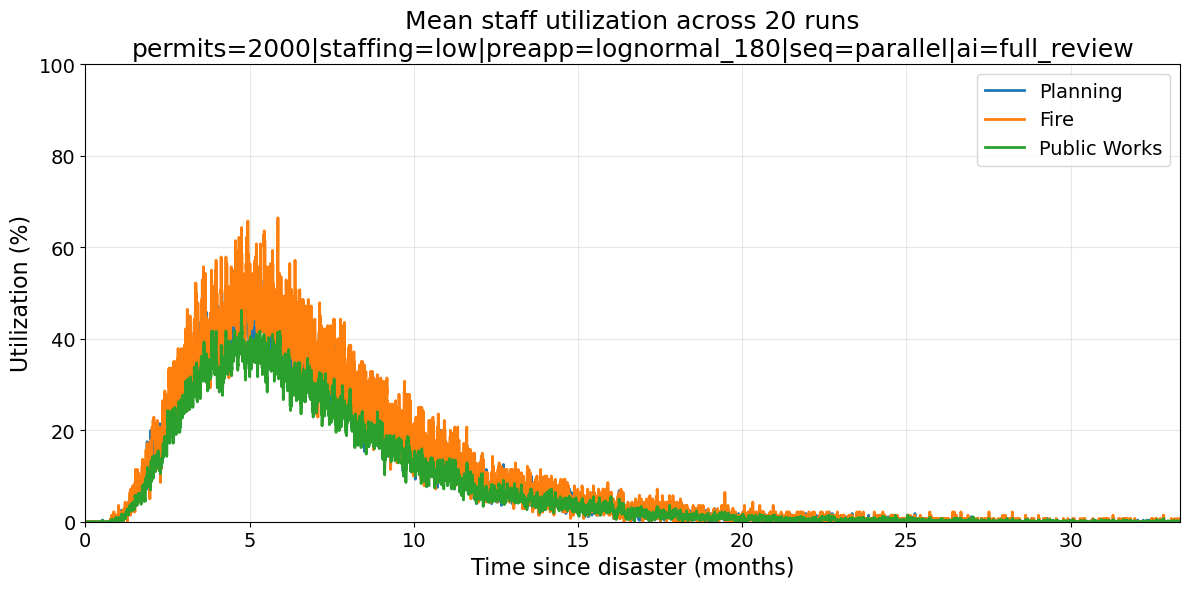

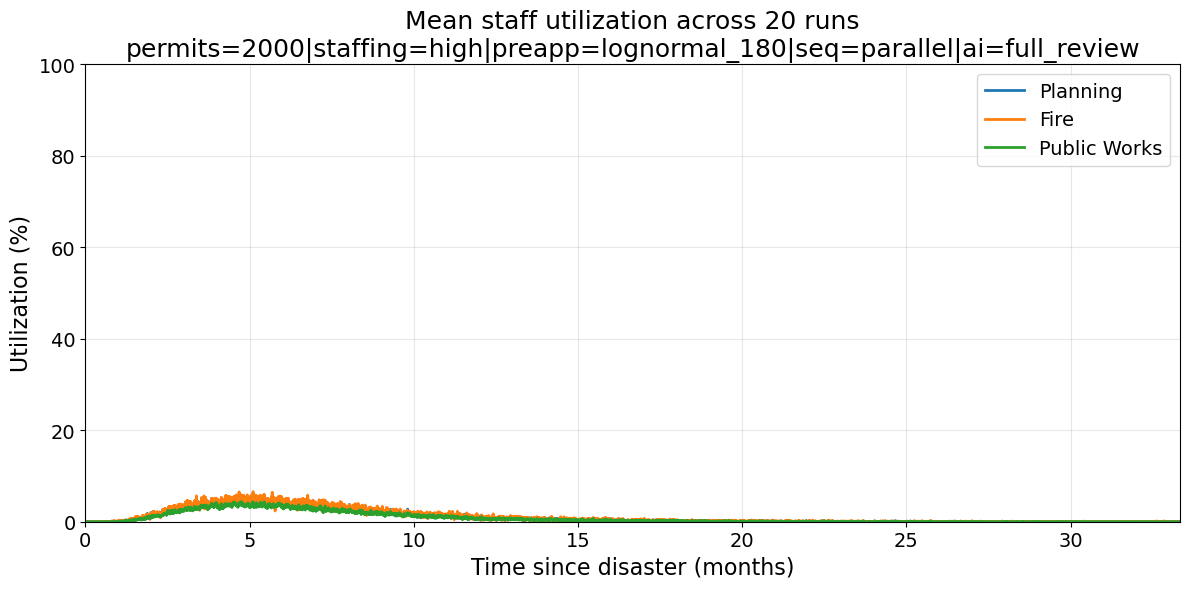

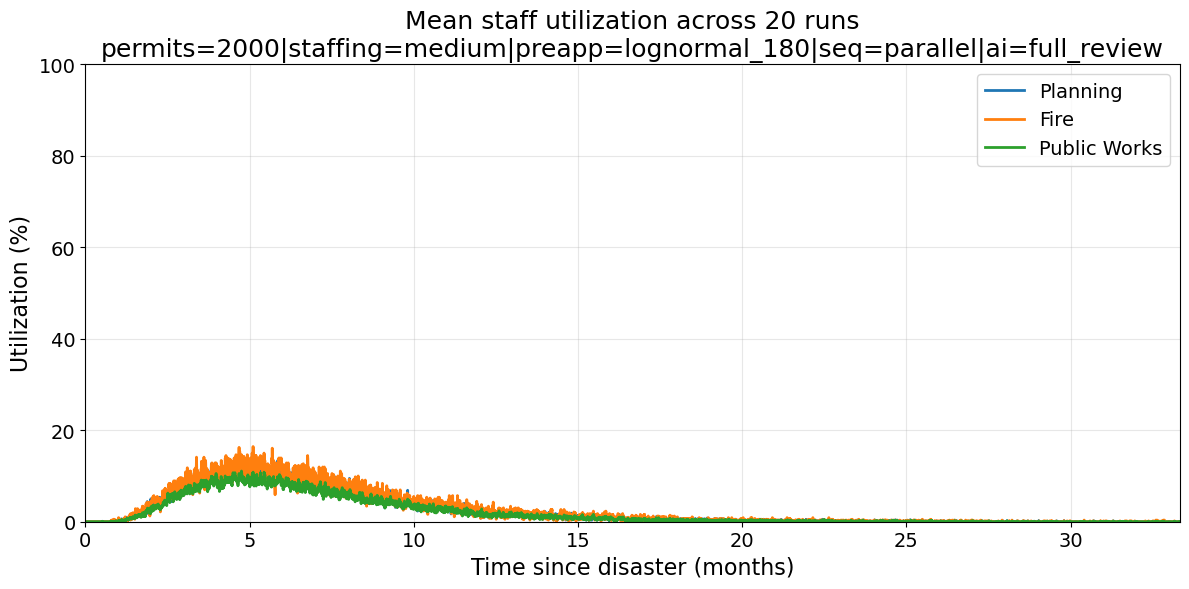

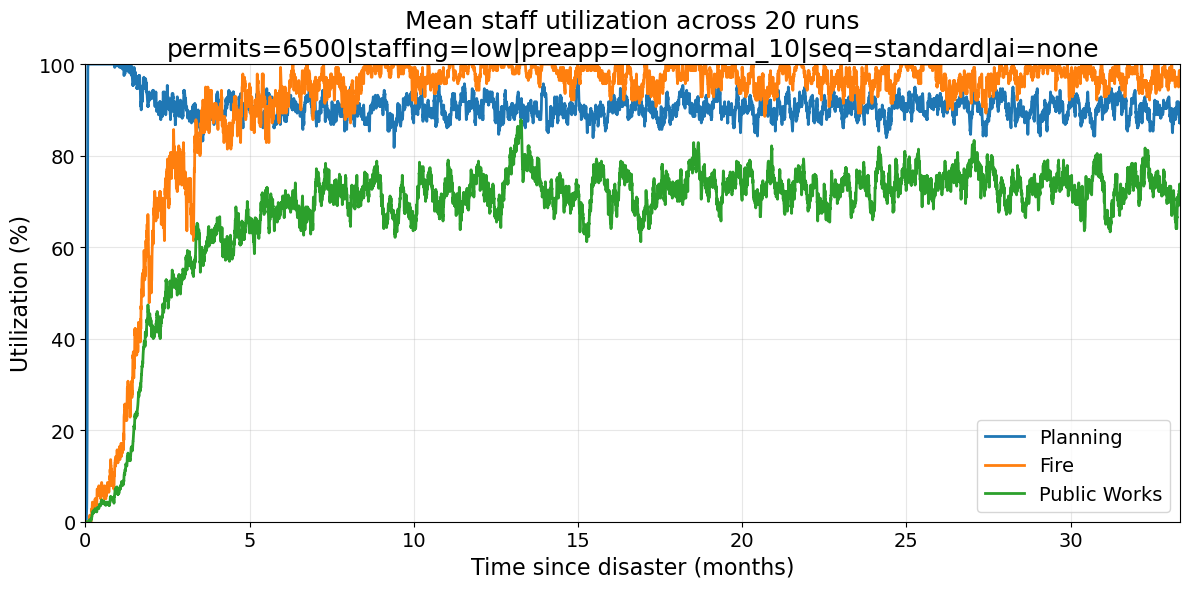

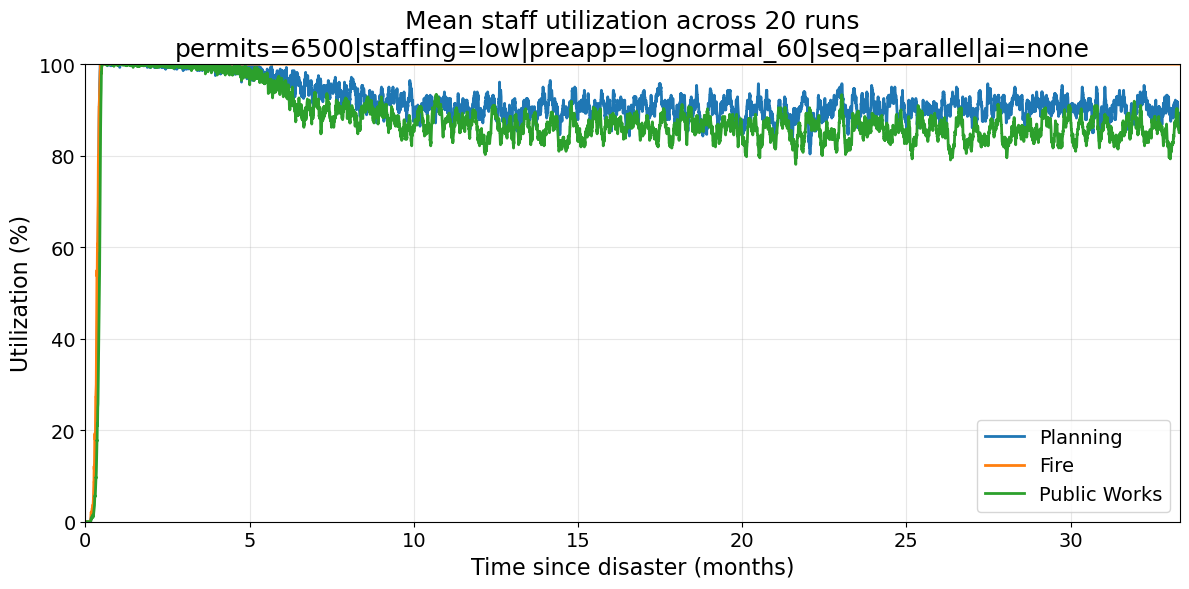

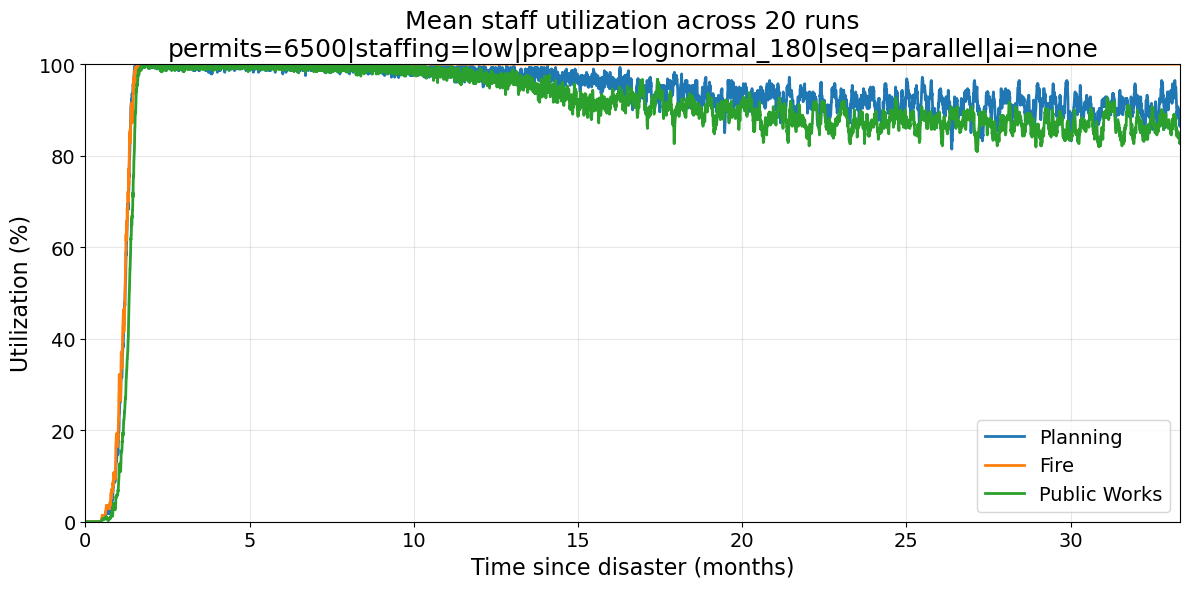

In [5]:
# --- Plot average utilization for selected scenarios ---
# Pick a few scenarios to compare; adjust list as needed.
selected = impact_df.sort_values("application_to_ready_mean_days").head(3)["scenario"].tolist()
selected += impact_df.sort_values("application_to_ready_mean_days", ascending=False).head(3)["scenario"].tolist()
selected = list(dict.fromkeys(selected))

for scenario_name in selected:
    util = util_by_scenario[scenario_name]
    plot_staff_utilization_series(
        util,
        as_percent=True,
        title=f"Mean staff utilization across {util['n_runs']} runs\n{scenario_name}",
        xlim=(0, min(1000, util["max_day"])),
        ylim=(0, 100),
    )


In [6]:
# --- Save results for reuse ---
from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / "policy_lever_impact_results.csv"
impact_df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")


Saved: results/policy_lever_impact_results.csv


### Figures: comparisons by cohort size and staffing

Loads `results/policy_lever_impact_results.csv` and builds **six** bar charts (permits × staffing).

Bars are **grouped by pre-application distribution** (lognormal 10 / 60 / 180). Within each group, five bars show policies in this order: standard/no AI, standard/initial review, standard/full review, sequential/no AI, parallel/no AI.

Figures are written under `results/`.

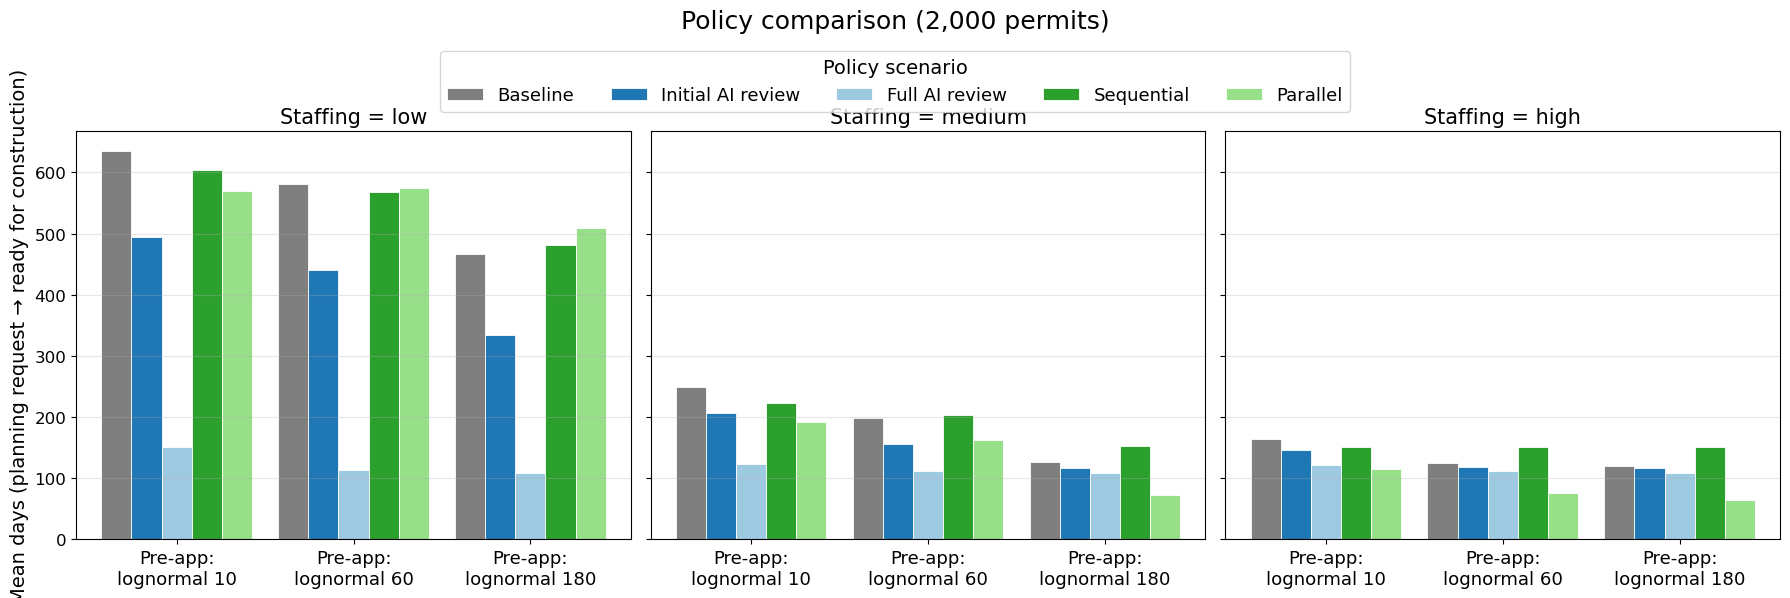

results/app_to_ready_policy_comparison_2000_permits.png


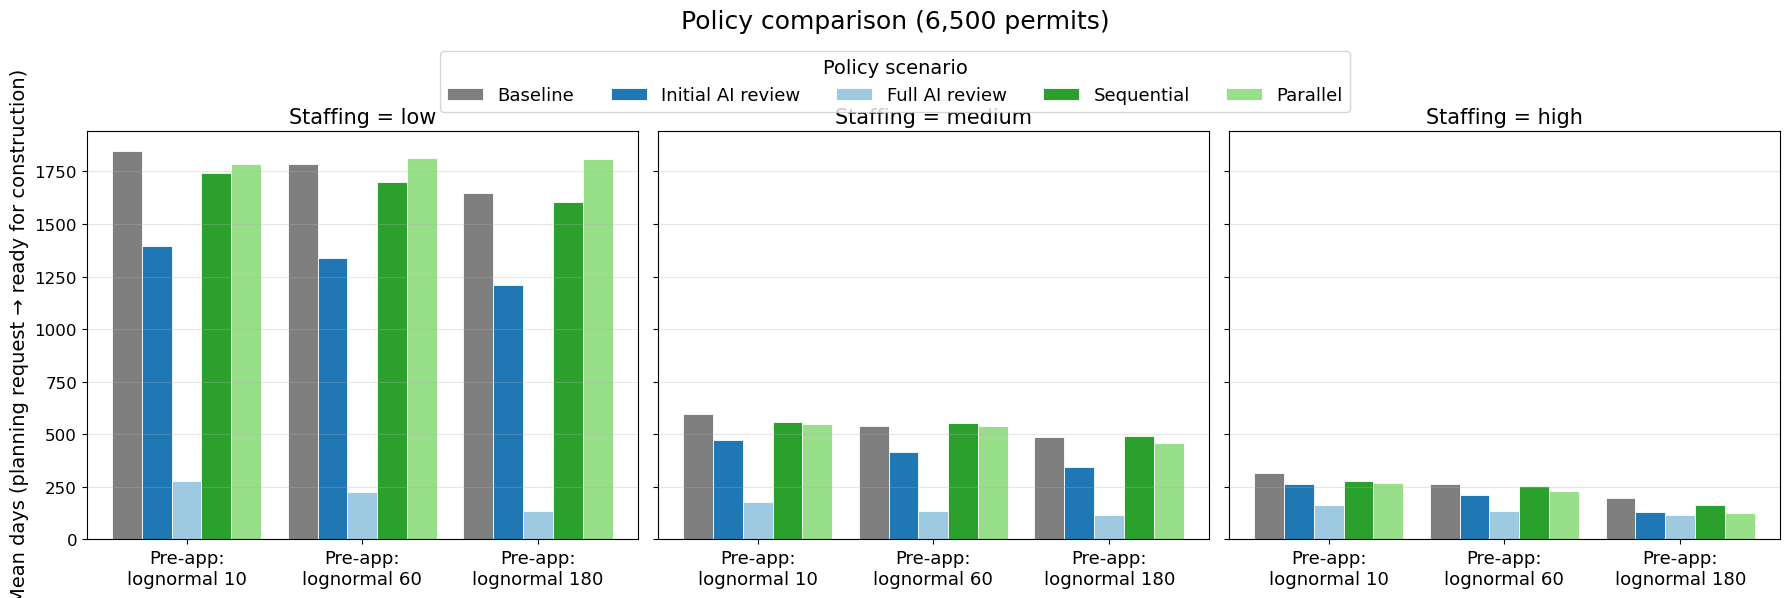

results/app_to_ready_policy_comparison_6500_permits.png


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_CSV = Path("results") / "policy_lever_impact_results.csv"
df_plot = pd.read_csv(RESULTS_CSV)

POLICY_ROWS = [
    ("standard", "none", "Baseline"),
    ("standard", "initial_check", "Initial AI review"),
    ("standard", "full_review", "Full AI review"),
    ("sequential", "none", "Sequential"),
    ("parallel", "none", "Parallel"),
]
PRE_APP_LEVELS = ["lognormal_10", "lognormal_60", "lognormal_180"]
PRE_APP_LABELS = {
    "lognormal_10": "Pre-app:\nlognormal 10",
    "lognormal_60": "Pre-app:\nlognormal 60",
    "lognormal_180": "Pre-app:\nlognormal 180",
}

policy_colors = [
    "#7f7f7f",  # Baseline (neutral gray)
    "#1f77b4",  # Initial AI review (blue)
    "#9ecae1",  # Full AI review (light blue)
    "#2ca02c",  # Sequential (green)
    "#98df8a",  # Parallel (light green)
]

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

permit_levels = sorted(df_plot["num_permits"].unique())
staffing_levels = ["low", "medium", "high"]

n_policies = len(POLICY_ROWS)
n_groups = len(PRE_APP_LEVELS)
x = np.arange(n_groups)
total_width = 0.85
bar_width = total_width / n_policies

for num_permits in permit_levels:
    fig, axes = plt.subplots(
        1,
        len(staffing_levels),
        figsize=(18, 5.5),
        sharey=True,
    )

    for c, staffing in enumerate(staffing_levels):
        ax = axes[c]
        subset = df_plot[
            (df_plot["num_permits"] == num_permits)
            & (df_plot["staffing_scenario"] == staffing)
            & (df_plot["pre_application_distribution"].isin(PRE_APP_LEVELS))
        ]

        for i, (seq, ai, policy_label) in enumerate(POLICY_ROWS):
            heights = []
            for pre in PRE_APP_LEVELS:
                row = subset[
                    (subset["sequential"] == seq)
                    & (subset["ai_review"] == ai)
                    & (subset["pre_application_distribution"] == pre)
                ]
                if len(row) != 1:
                    raise ValueError(
                        f"Expected 1 row for permits={num_permits}, staffing={staffing}, "
                        f"pre={pre}, sequential={seq}, ai={ai}; got {len(row)}"
                    )
                heights.append(float(row["application_to_ready_mean_days"].iloc[0]))
            offset = bar_width * (i - (n_policies - 1) / 2)
            ax.bar(
                x + offset,
                heights,
                bar_width,
                label=policy_label,
                color=policy_colors[i],
                edgecolor="white",
                linewidth=0.6,
            )

        ax.set_xticks(x)
        ax.set_xticklabels([PRE_APP_LABELS[p] for p in PRE_APP_LEVELS], fontsize=13)
        ax.tick_params(axis="y", labelsize=12)
        ax.set_title(f"Staffing = {staffing}", fontsize=15)
        ax.grid(axis="y", alpha=0.3)
        if c == 0:
            ax.set_ylabel("Mean days (planning request → ready for construction)", fontsize=14)
        else:
            ax.set_ylabel("")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Policy scenario",
        loc="upper center",
        ncol=5,
        bbox_to_anchor=(0.5, 1.02),
        fontsize=13,
        title_fontsize=14,
    )
    fig.suptitle(
        f"Policy comparison ({num_permits:,} permits)",
        fontsize=18,
        y=1.08,
    )
    plt.tight_layout()

    out_path = results_dir / f"app_to_ready_policy_comparison_{num_permits}_permits.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(out_path)
